# Correlação e Regressão Simples/Multivariada 

In [98]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import scipy.stats as stats

# 1.

In [99]:
df = pd.read_csv("house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,n,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,n,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,n,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,n,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,n,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [100]:
for column in df.columns:
    print(f"Coluna: {column}, Tipo: {df[column].dtype}")

Coluna: id, Tipo: int64
Coluna: date, Tipo: object
Coluna: price, Tipo: float64
Coluna: bedrooms, Tipo: int64
Coluna: bathrooms, Tipo: float64
Coluna: sqft_living, Tipo: int64
Coluna: sqft_lot, Tipo: int64
Coluna: floors, Tipo: float64
Coluna: waterfront, Tipo: object
Coluna: view, Tipo: int64
Coluna: condition, Tipo: int64
Coluna: grade, Tipo: int64
Coluna: sqft_above, Tipo: int64
Coluna: sqft_basement, Tipo: int64
Coluna: yr_built, Tipo: int64
Coluna: yr_renovated, Tipo: int64
Coluna: zipcode, Tipo: int64
Coluna: lat, Tipo: float64
Coluna: long, Tipo: float64
Coluna: sqft_living15, Tipo: int64
Coluna: sqft_lot15, Tipo: int64


In [101]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

In [102]:
df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9999 entries, 0 to 9998
Series name: date
Non-Null Count  Dtype         
--------------  -----         
9999 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 78.2 KB


Matriz de correlação:



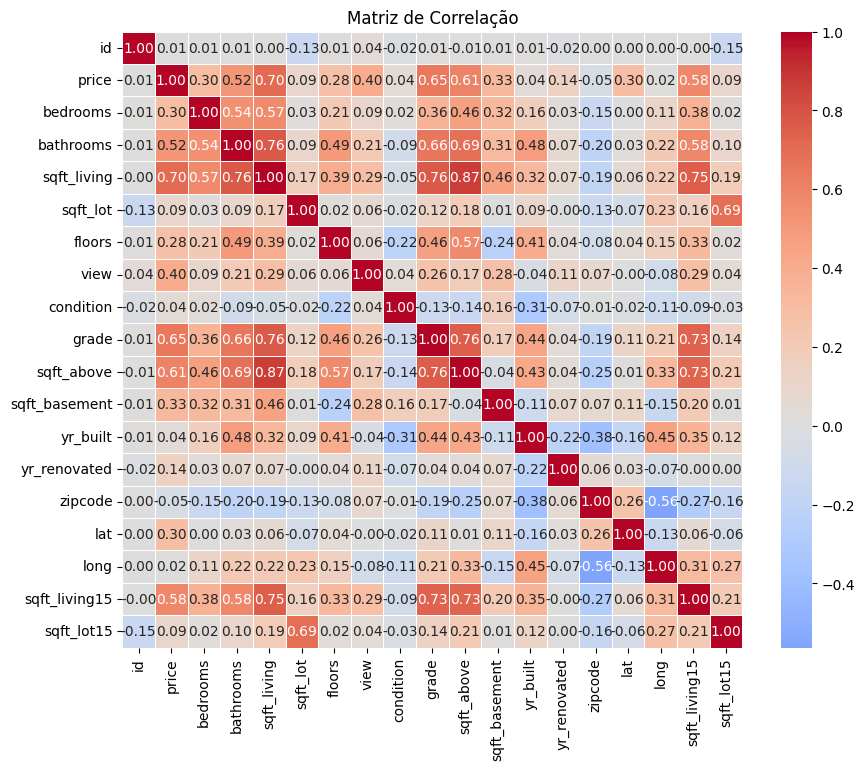

In [103]:
# 1.colunas numéricas para calcular a matriz de correlação
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()
print("Matriz de correlação:\n")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

In [104]:
# correlation_matrix

In [105]:
# correlação entre 'price' e 'bedrooms'
corr_price_bedrooms = correlation_matrix.loc['price', 'bedrooms']
print(f"Correlação entre 'price' e 'bedrooms': {corr_price_bedrooms:.4f}")

Correlação entre 'price' e 'bedrooms': 0.2992


In [106]:
filtered_df = df[df['sqft_living'] > 2000]

filtered_numeric_df = filtered_df.select_dtypes(include=['int64', 'float64'])
filtered_corr = filtered_numeric_df.corr()

corr_price_bedrooms_filtered = filtered_corr.loc['price', 'bedrooms']

print(f"Correlação entre 'price' e 'bedrooms' para casas com 'sqft_living' > 2000: {corr_price_bedrooms_filtered:.4f}")

Correlação entre 'price' e 'bedrooms' para casas com 'sqft_living' > 2000: 0.1191


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             9999 non-null   int64         
 1   date           9999 non-null   datetime64[ns]
 2   price          9999 non-null   float64       
 3   bedrooms       9999 non-null   int64         
 4   bathrooms      9999 non-null   float64       
 5   sqft_living    9999 non-null   int64         
 6   sqft_lot       9999 non-null   int64         
 7   floors         9999 non-null   float64       
 8   waterfront     9999 non-null   object        
 9   view           9999 non-null   int64         
 10  condition      9999 non-null   int64         
 11  grade          9999 non-null   int64         
 12  sqft_above     9999 non-null   int64         
 13  sqft_basement  9999 non-null   int64         
 14  yr_built       9999 non-null   int64         
 15  yr_renovated   9999 n

In [108]:
#2.
df_filtrado = df[df['bathrooms'] >= 2]

# Calcular a correlação entre 'price' e 'sqft_living'
correlacao = df_filtrado['price'].corr(df_filtrado['sqft_living'])

correlacao

0.7067107107996193

In [109]:
# 3.
# Aqui escolhi a quantidade de resgistros para a correlação.
correlacao_por_banheiro = (
    df.groupby('bathrooms')
    .filter(lambda x: len(x) > 1)
    .groupby('bathrooms')
    .apply(lambda x: x['price'].corr(x['sqft_living']))
)

pd.DataFrame(correlacao_por_banheiro).head()

,0
bathrooms,
0.00,0.916837
0.75,0.357178
1.00,0.359529
1.25,0.167331
1.50,0.423405


In [110]:
#4.
casas_grandes = df[df['sqft_living'] > 3000]

correlacao_condition_price = casas_grandes['condition'].corr(casas_grandes['price'])

correlacao_condition_price

0.10527844723732617

In [111]:
# 5.

casas_tres_quartos = df[df['bedrooms'] >= 3]

correlacao_lat_price = casas_tres_quartos['lat'].corr(casas_tres_quartos['price'])


correlacao_long_price = casas_tres_quartos['long'].corr(casas_tres_quartos['price'])

correlacao_lat_price, correlacao_long_price

(0.31255514248432165, -0.007275306992926935)

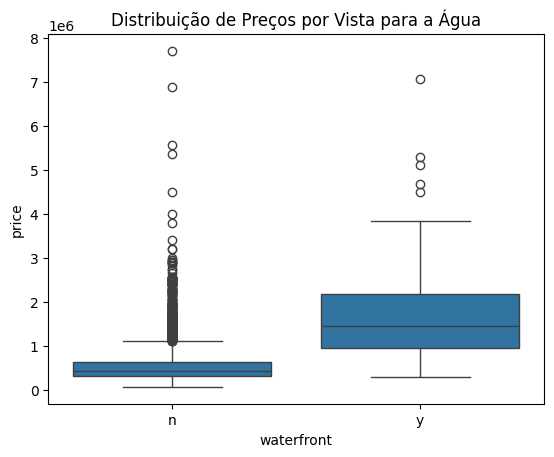

In [112]:
#6.
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Distribuição de Preços por Vista para a Água')
plt.show()

In [113]:
df['waterfront'] = df['waterfront'].astype('category')

modelo = smf.ols('price ~ C(waterfront)', data=df).fit()

anova_table = sm.stats.anova_lm(modelo, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(waterfront),1.250790e+14,1.0,964.573325,2.973808e-202
Residual,1.296339e+15,9997.0,NaN,NaN


---

# 2.

In [114]:
df2 = pd.read_csv("car_price.csv")
df2.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [115]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874 entries, 0 to 1873
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                1874 non-null   object 
 1   Model               1874 non-null   object 
 2   Price               1874 non-null   int64  
 3   Year                1874 non-null   int64  
 4   Kilometer           1874 non-null   int64  
 5   Fuel Type           1874 non-null   object 
 6   Transmission        1874 non-null   object 
 7   Location            1874 non-null   object 
 8   Color               1874 non-null   object 
 9   Owner               1874 non-null   object 
 10  Seller Type         1874 non-null   object 
 11  Engine              1874 non-null   object 
 12  Max Power           1874 non-null   object 
 13  Max Torque          1874 non-null   object 
 14  Drivetrain          1874 non-null   object 
 15  Length              1874 non-null   float64
 16  Width 

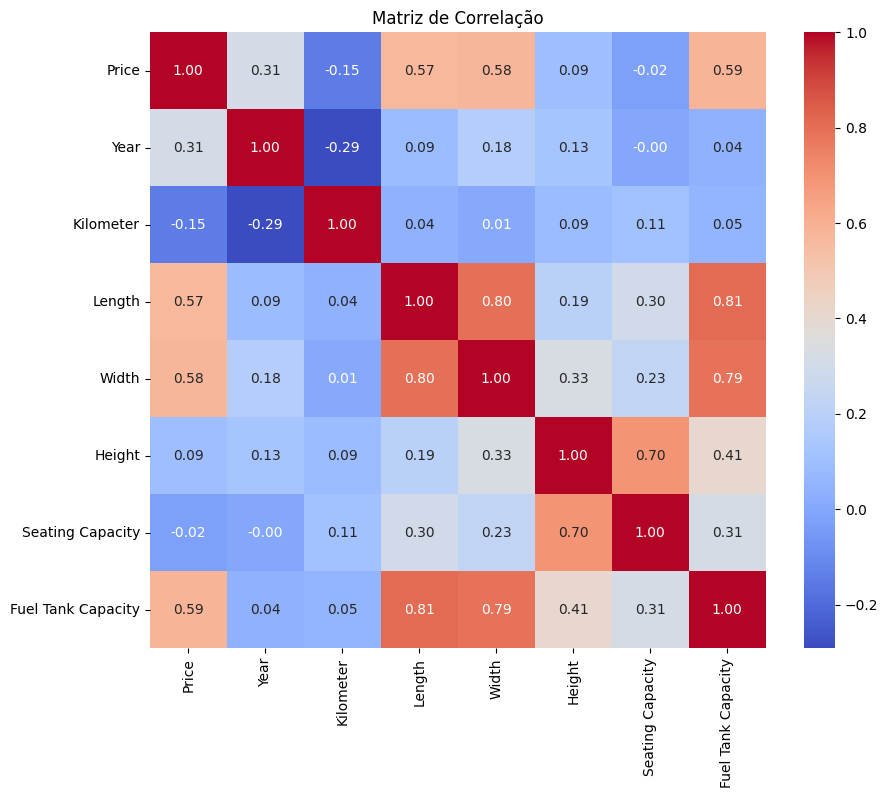

In [116]:
numeric_df2 = df2.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlação')
plt.show()

In [117]:
# correlações positivas, negativas e neutras.
correlacoes_positivas = correlation_matrix[correlation_matrix > 0].stack().reset_index()
correlacoes_negativas = correlation_matrix[correlation_matrix < 0].stack().reset_index()
correlacoes_neutras = correlation_matrix[correlation_matrix == 0].stack().reset_index()

print("Exemplos de correlações positivas:\n")
print(correlacoes_positivas.sample(3))

print("\nExemplos de correlações negativas:\n")
print(correlacoes_negativas.sample(3))

if not correlacoes_neutras.empty:
    print("\nExemplos de correlações neutras:\n")
    print(correlacoes_neutras.sample(3)) 
else:
    print("\nNão há correlações neutras entre as variáveis.")

Exemplos de correlações positivas:

      level_0             level_1         0
17  Kilometer  Fuel Tank Capacity  0.052447
23     Length              Height  0.194704
24     Length    Seating Capacity  0.298527

Exemplos de correlações negativas:

            level_0 level_1         0
4         Kilometer   Price -0.147276
7  Seating Capacity    Year -0.000113
5         Kilometer    Year -0.291740

Não há correlações neutras entre as variáveis.


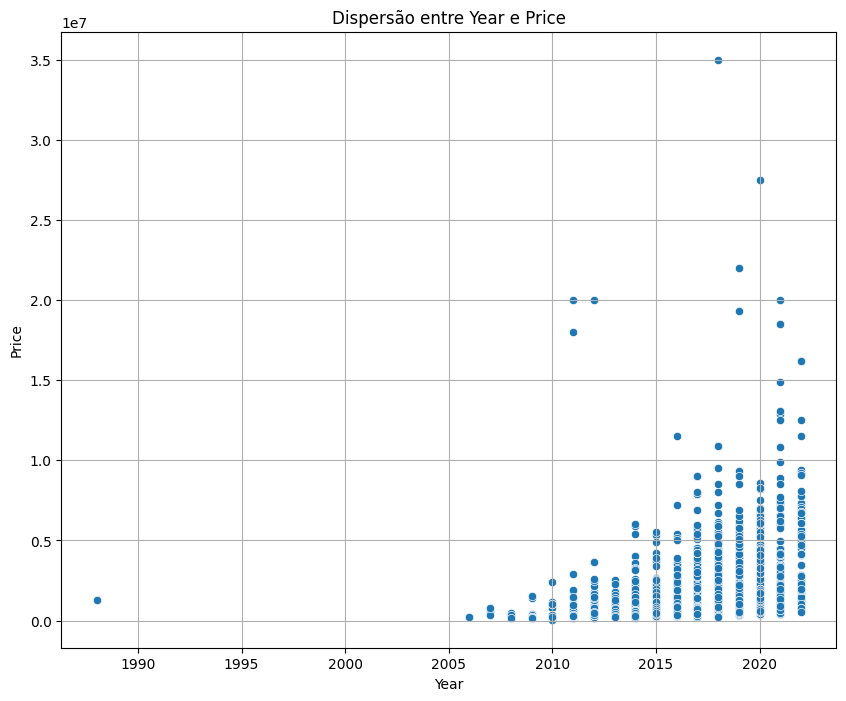

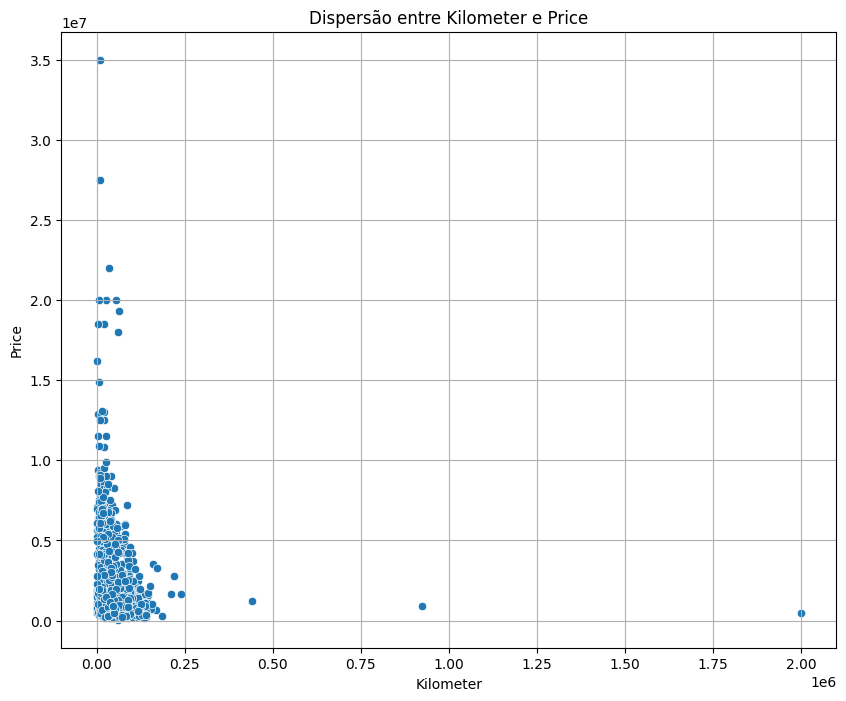

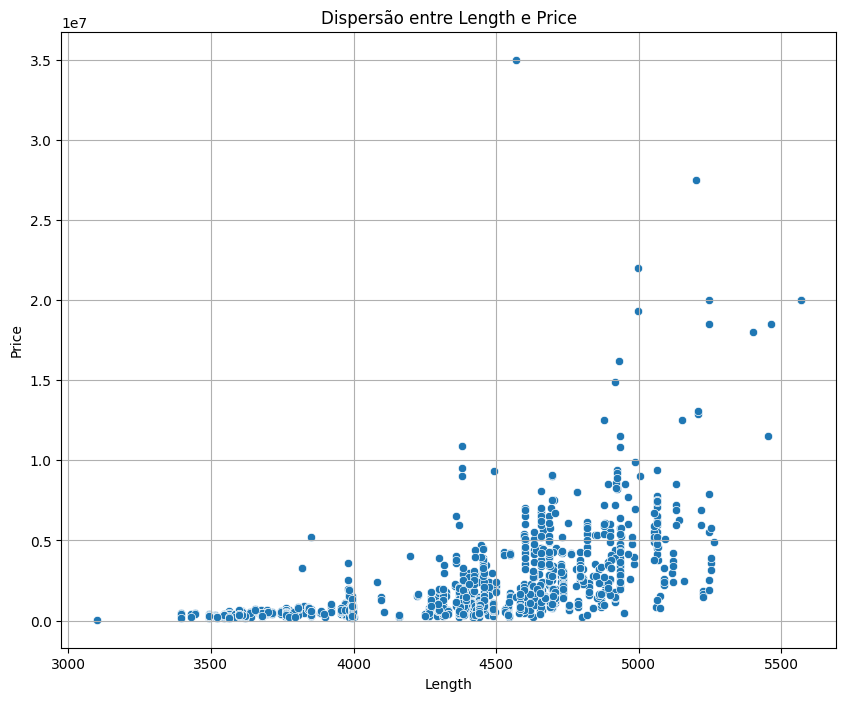

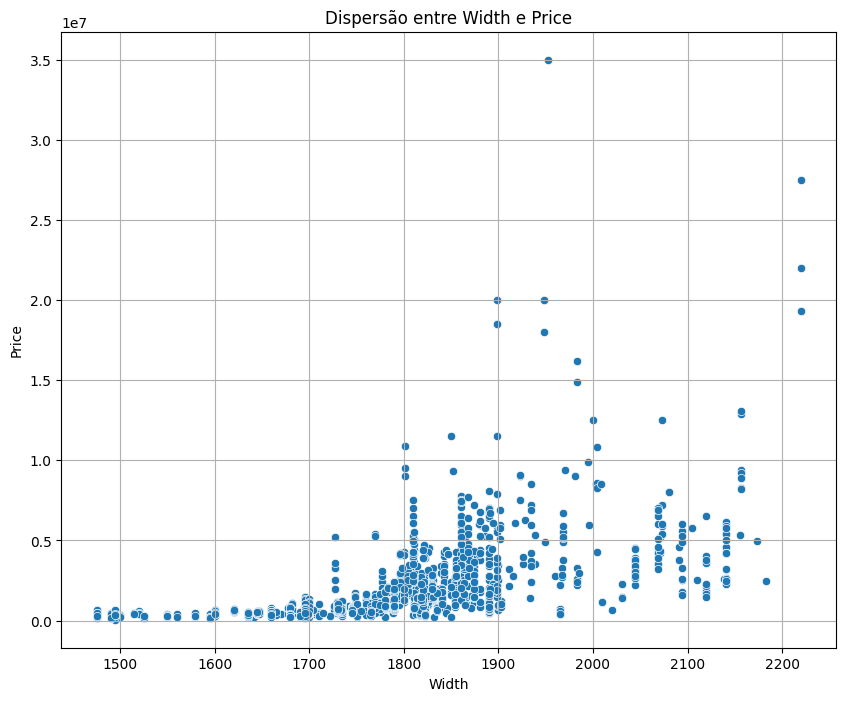

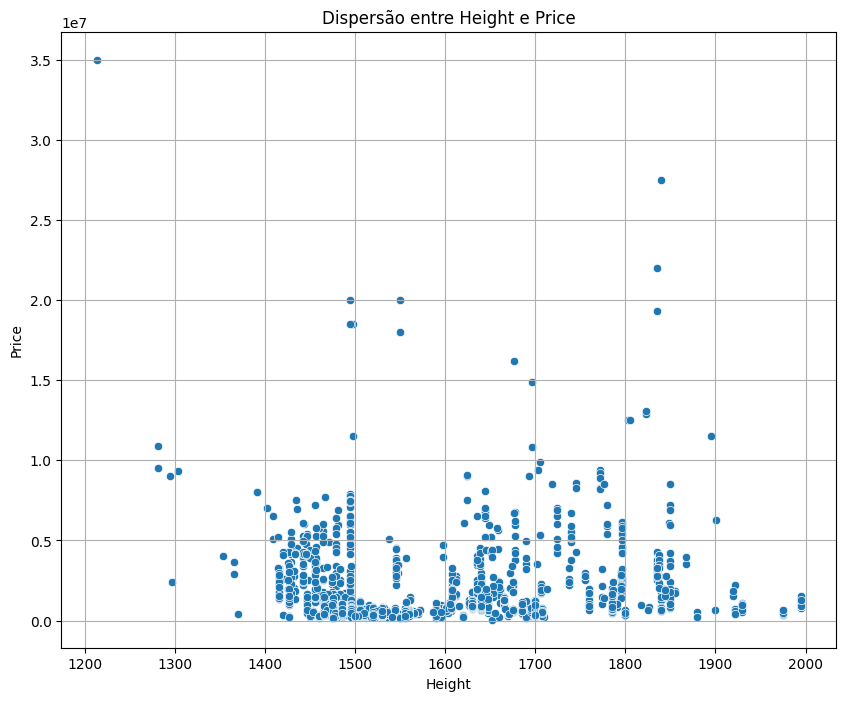

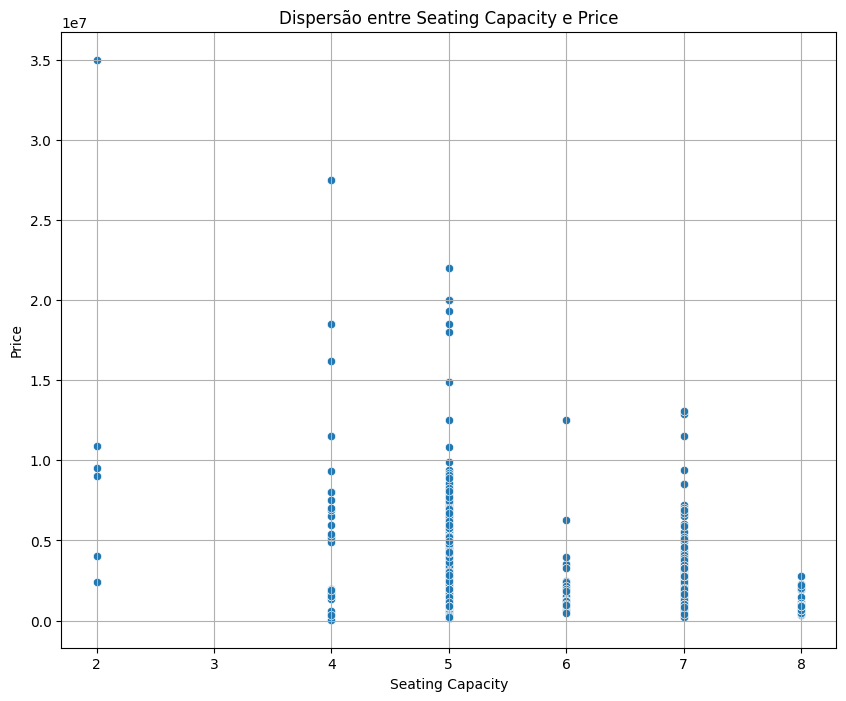

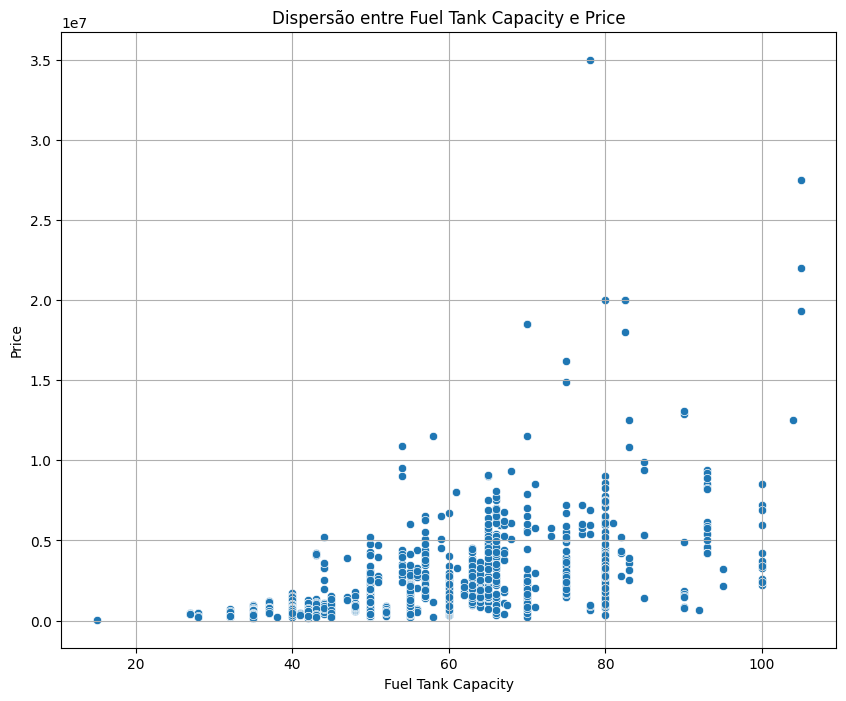

In [118]:
# 8.
variaveis_numericas = df2.select_dtypes(include=['float64', 'int64']).columns.drop('Price')

for var in variaveis_numericas:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df2, x=var, y='Price')
    plt.title(f'Dispersão entre {var} e Price')
    plt.xlabel(var)
    plt.ylabel('Price')
    plt.grid(True)
    plt.show()

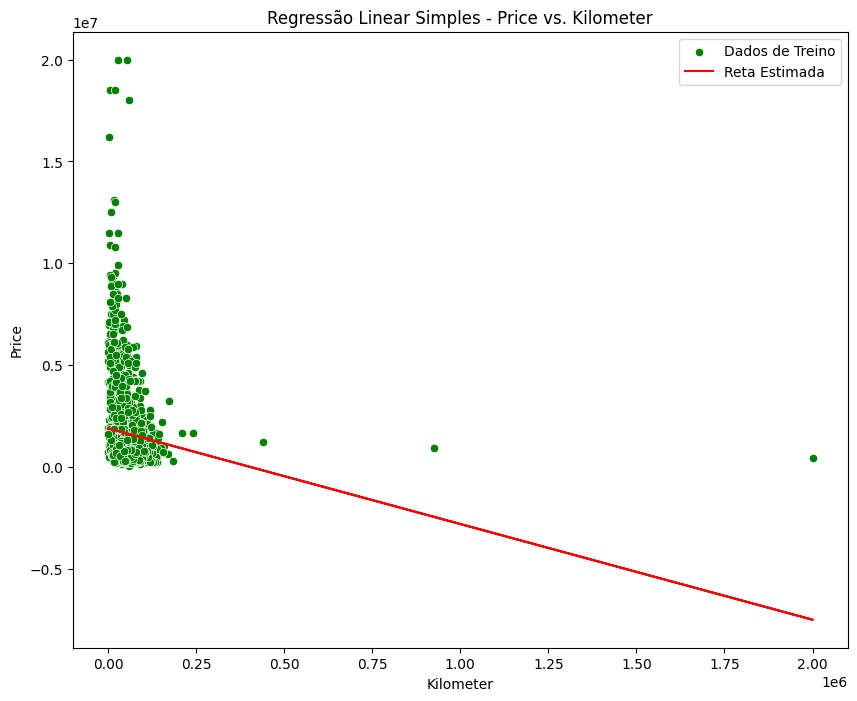

In [119]:
#9.
X = df2[['Kilometer']]
y = df2['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_sm = sm.add_constant(X_train)
modelo_sm = sm.OLS(y_train, X_sm).fit()

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_train['Kilometer'], y=y_train, color='green', label='Dados de Treino')
plt.plot(X_train['Kilometer'], modelo_sm.predict(X_sm), color='red', label='Reta Estimada')
plt.xlabel('Kilometer')
plt.ylabel('Price')
plt.title('Regressão Linear Simples - Price vs. Kilometer')
plt.legend()

plt.show()

In [120]:
modelo_sm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     31.32
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           2.60e-08
Time:                        18:16:14   Log-Likelihood:                -23930.
No. Observations:                1499   AIC:                         4.786e+04
Df Residuals:                    1497   BIC:                         4.787e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.889e+06   7.02e+04     26.921      0.000    1.75e+06    2.03e+06
Kilometer     -4.7030      0.840     -5.597      0.000      -6.351      -3.055
==============================================================================
Omnibus:                     1218.938   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            29668.311
Skew:                           3.701   Prob(JB):                         0.00
Kurtosis:                      23.499   Cond. No.                     1.09e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.09e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

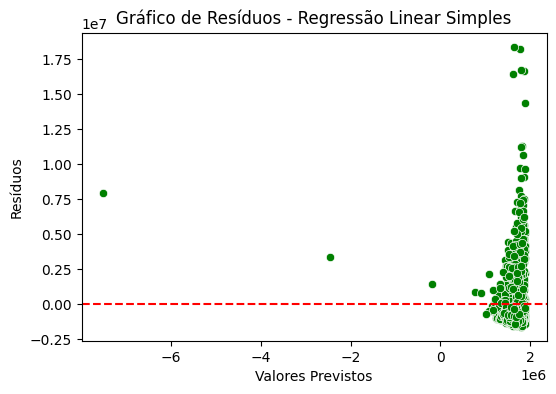

In [121]:
# 10.
residuos = y_train - modelo_sm.predict(X_sm)


plt.figure(figsize=(6, 4))
sns.scatterplot(x=modelo_sm.predict(X_sm), y=residuos, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos - Regressão Linear Simples')
plt.show()

In [122]:
#11.
variaveis_independentes = ['Year', 'Kilometer', 'Seating Capacity', 'Fuel Tank Capacity', 'Length', 'Width', 'Height']
X = df2[variaveis_independentes]
y = df2['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_sm = sm.add_constant(X_train)
modelo_multivariado = sm.OLS(y_train, X_sm).fit()

modelo_multivariado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     240.5
Date:                Mon, 14 Oct 2024   Prob (F-statistic):          1.97e-239
Time:                        18:16:14   Log-Likelihood:                -23379.
No. Observations:                1499   AIC:                         4.677e+04
Df Residuals:                    1491   BIC:                         4.682e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const              -3.474e+08   2.65e+07    -13.114      0.000   -3.99e+08   -2.95e+08
Year                1.691e+05   1.33e+04     12.756      0.000    1.43e+05    1.95e+05
Kilometer             -2.7139      0.611     -4.440      0.000      -3.913      -1.515
Seating Capacity   -4.581e+05   6.98e+04     -6.559      0.000   -5.95e+05   -3.21e+05
Fuel Tank Capacity  4.912e+04   5146.945      9.544      0.000     3.9e+04    5.92e+04
Length              1450.5733    185.316      7.828      0.000    1087.066    1814.080
Width               1399.1847    553.779      2.527      0.012     312.917    2485.452
Height              -454.6265    463.207     -0.981      0.327   -1363.233     453.980
==============================================================================
Omnibus:                     1454.390   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            86809.707
Skew:                           4.484   Prob(JB):                         0.00
Kurtosis:                      39.186   Cond. No.                     5.95e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.95e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

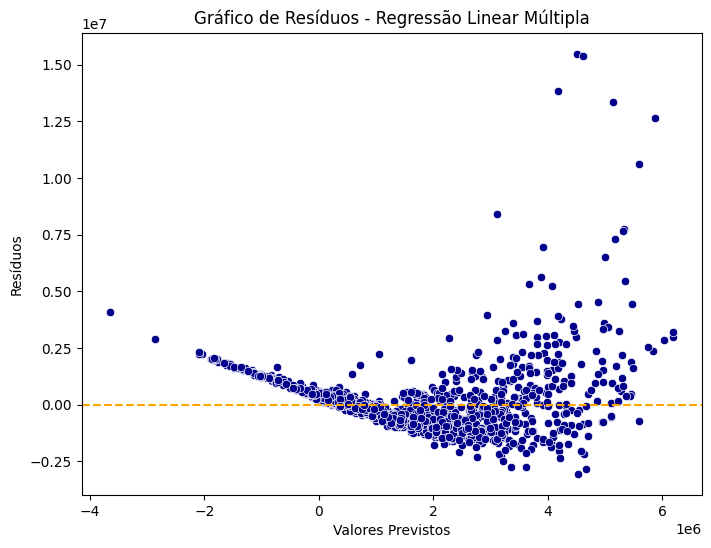

In [123]:
residuos = y_train - modelo_multivariado.predict(X_sm)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=modelo_multivariado.predict(X_sm), y=residuos, color='darkblue')
plt.axhline(y=0, color='orange', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Gráfico de Resíduos - Regressão Linear Múltipla')

plt.show()